In [97]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [98]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_03/cvMeasure"
os.makedirs(figureroot, exist_ok=True)

In [99]:
load_dir = "../system_03/results/cvMeasure/"
load_str = datetime.datetime(2024, 3, 31)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 20


In [100]:
sigVar = np.array([0.01, 0.1, 1, 2])
iE = 0.25 / params['gamma'] - params['i_e2']

iPert = np.array([0, 0.15, 0.25, 0.35, 0.5]) / params['gamma']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

seVals = np.array([2.5, 7.5, 13.5]); seSteps = len(seVals)
siVals = np.array([4.4, 13.5, 16.5]); siSteps = len(siVals) 

In [105]:
varInd = 3
path_ = os.path.join(results_dir, f"Imod_{iE + params['i_e2']:.3f}mV_sigVar_{sigVar[varInd]:.2f}.pkl")

CV = np.zeros((kSteps, 4))
CVVar = np.zeros((kSteps, 4))
sigE = np.zeros((kSteps, 4))
sigI = np.zeros((kSteps, 4))

cv_results = pickle.load(open(path_, 'rb'))

_cvMean = abs(cv_results['CV_mean'])
_cvVar = cv_results['CV_var']

CV[:, 0] = _cvMean[:, 0, 0]; CVVar[:, 0] = _cvVar[:, 0, 0]
CV[:, 1] = _cvMean[:, 0, -1]; CVVar[:, 1] = _cvVar[:, 0, -1]
CV[:, 2] = _cvMean[:, -2, 0]; CVVar[:, 2] = _cvVar[:, -2, 0]
CV[:, 3] = _cvMean[:, -2, -1]; CVVar[:, 3] = _cvVar[:, -2, -1]

CVVAr = CVVar ** 2

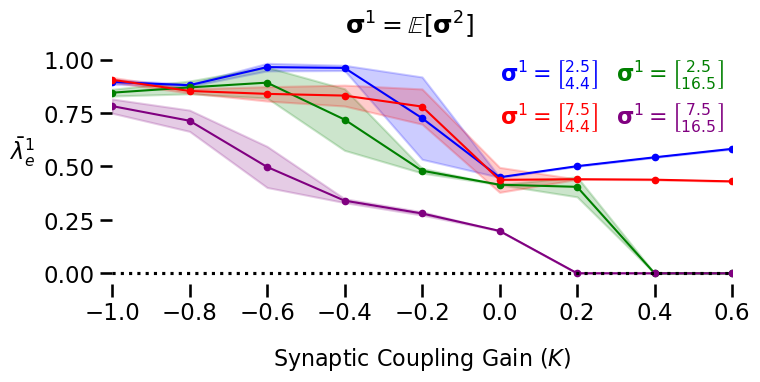

In [106]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals[:-1], CV[:-1, 0], '.-', color = 'b', linewidth=1.5)
plt.fill_between(kVals[:-1], CV[:-1, 0] - CVVar[:-1, 0], CV[:-1, 0] + CVVar[:-1, 0], alpha=0.2, color='b')
plt.text(0, 0.9, r'$\mathbf{\sigma}^1 =  \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = 'b',  fontsize=16)

plt.plot(kVals[:-1], CV[:-1, 1], '.-', color = 'g', linewidth=1.5)
plt.fill_between(kVals[:-1], CV[:-1, 1] - CVVar[:-1, 1], CV[:-1, 1] + CVVar[:-1, 1], alpha=0.2, color='g')
plt.text(0.3, 0.9, r'$\mathbf{\sigma}^1 =  \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(kVals[:-1], CV[:-1, 2], '.-', color = 'r', linewidth=1.5)
plt.fill_between(kVals[:-1], CV[:-1, 2] - CVVar[:-1, 2], CV[:-1, 2] + CVVar[:-1, 2], alpha=0.2, color='r')
plt.text(0., 0.7, r'$\mathbf{\sigma}^1 =  \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = 'r',  fontsize=16)

plt.plot(kVals[:-1], CV[:-1, 3], '.-', color = 'purple', linewidth=1.5)
plt.fill_between(kVals[:-1], CV[:-1, 3] - CVVar[:-1, 3], CV[:-1, 3] + CVVar[:-1, 3], alpha=0.2, color='purple')
plt.text(0.3, 0.7, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = 'purple',  fontsize=16)

plt.text(-0.4, 1.12, r"$\mathbf{\sigma}^1 = \mathbb{E}[\mathbf{\sigma}^2] $",  fontsize=18)

plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\bar{\lambda}^1_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals[:-1]))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigVar_{sigVar[varInd]:.2f}_K.png"), dpi=300, bbox_inches='tight')
    

In [110]:
CV = np.zeros((len(sigVar), kSteps, 4))
CVVar = np.zeros((len(sigVar), kSteps, 4))

for varInd in range(len(sigVar)):
    path_ = os.path.join(results_dir, f"Imod_{iE + params['i_e2']:.3f}mV_sigVar_{sigVar[varInd]:.2f}.pkl")
    cv_results = pickle.load(open(path_, 'rb'))

    _cvMean = abs(cv_results['CV_mean'])
    _cvVar = cv_results['CV_var']
 
    CV[varInd, :, 0] = _cvMean[:, 0, 0]; CVVar[varInd, :, 0] = _cvVar[:, 0, 0]
    CV[varInd, :, 1] = _cvMean[:, 0, -1]; CVVar[varInd, :, 1] = _cvVar[:, 0, -1]
    CV[varInd, :, 2] = _cvMean[:, -2, 0]; CVVar[varInd, :, 2] = _cvVar[:, -2, 0]
    CV[varInd, :, 3] = _cvMean[:, -2, -1]; CVVar[varInd, :, 3] = _cvVar[:, -2, -1]

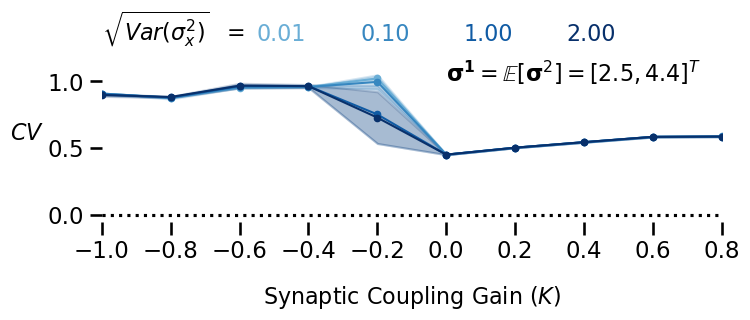

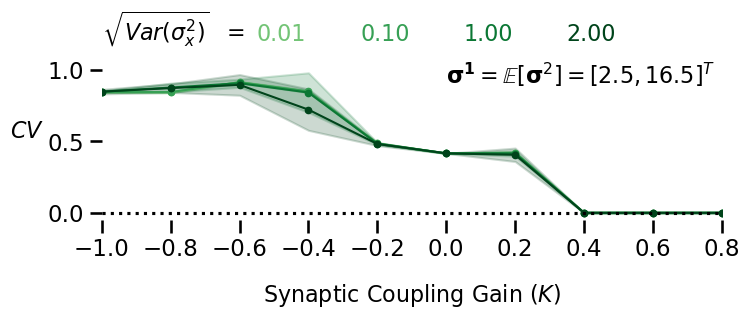

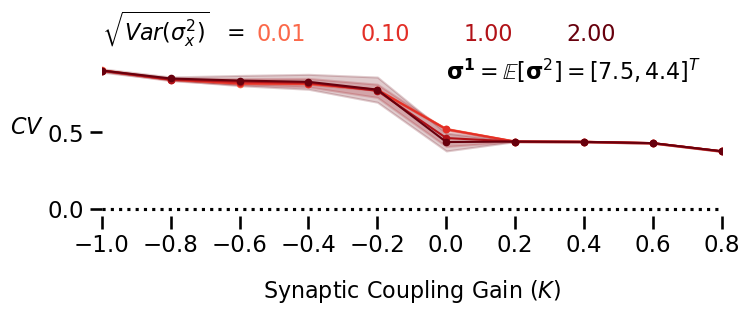

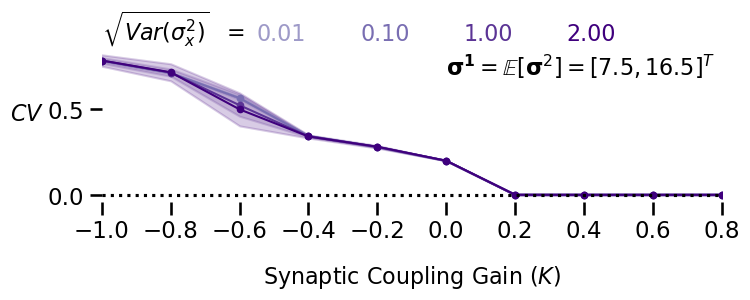

In [127]:
colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 1.3, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals, CV[i, :, 0], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals, CV[i, :, 0] - CVVar[i, :, 0], CV[i, :, 0] + CVVar[i, :, 0], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 1.3, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 1.0, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-1])
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_2.5_sigi_4.4_K.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 1.2, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals, CV[i, :, 1], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals, CV[i, :, 1] - CVVar[i, :, 1], CV[i, :, 1] + CVVar[i, :, 1], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 1.2, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, .9, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-1])
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_2.5_sigi_16.5_K.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 1.1, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals, CV[i, :, 2], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals, CV[i, :, 2] - CVVar[i, :, 2], CV[i, :, 2] + CVVar[i, :, 2], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 1.1, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 0.85, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-1])
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_7.5_sigi_4.4_K.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Purples')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, .9, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals, CV[i, :, 3], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals, CV[i, :, 3] - CVVar[i, :, 3], CV[i, :, 3] + CVVar[i, :, 3], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 0.9, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 0.7, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-1])
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)   
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_7.5_sigi_16.5_K.png"), dpi=300, bbox_inches="tight")
plt.show()

In [94]:
CV = np.zeros((len(sigVar), len(iPert), 4))
CVVar = np.zeros((len(sigVar), len(iPert), 4))

Kind = 6

for varInd in range(len(sigVar)):
    _temp = []
    _sortpaths = []

    for path_ in file_paths:
        if f"_sigVar_{sigVar[varInd]:.2f}" not in path_:
            continue
        Basename = os.path.basename(path_).split('.pkl')[0]
        I = float(Basename.split('Imod_')[-1].split('mV_')[0])
        _temp.append(I)
        _sortpaths.append(path_)

    _temp = np.array(_temp)
    Isort = np.argsort(_temp)

    _sortpaths = np.array(_sortpaths)
    _sortpaths = _sortpaths[Isort]
    iVals = _temp[Isort]
    iVals -= params['i_e2']

    for nf, path_ in enumerate(_sortpaths):
        cv_results = pickle.load(open(path_, 'rb'))

        _cvMean = abs(cv_results['CV_mean'])
        _cvVar = cv_results['CV_var']

        CV[varInd, nf, 0] = _cvMean[Kind, 0, 0]; CVVar[varInd, nf, 0] = _cvVar[Kind, 0, 0]
        CV[varInd, nf, 1] = _cvMean[Kind, 0, -1]; CVVar[varInd, nf, 1] = _cvVar[Kind, 0, -1]
        CV[varInd, nf, 2] = _cvMean[Kind, -2, 0]; CVVar[varInd, nf, 2] = _cvVar[Kind, -2, 0]
        CV[varInd, nf, 3] = _cvMean[Kind, -2, -1]; CVVar[varInd, nf, 3] = _cvVar[Kind, -2, -1]

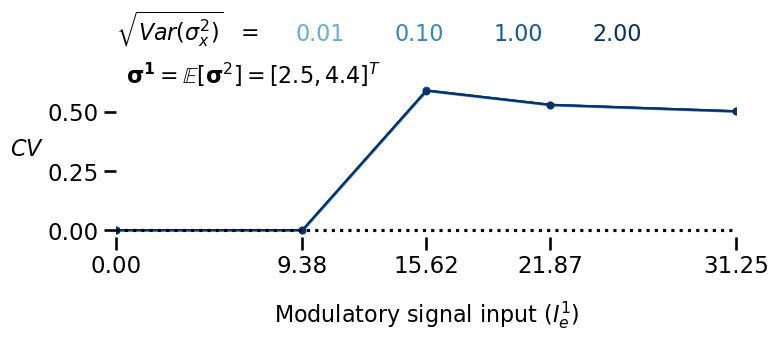

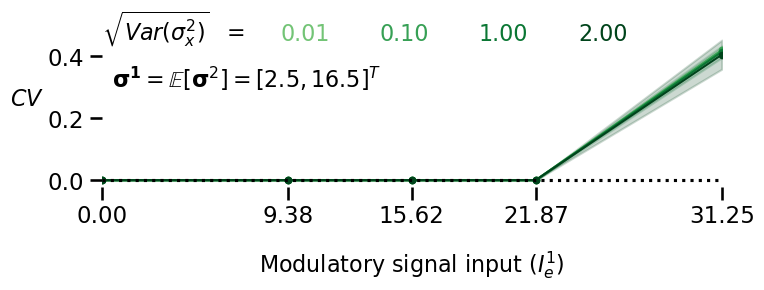

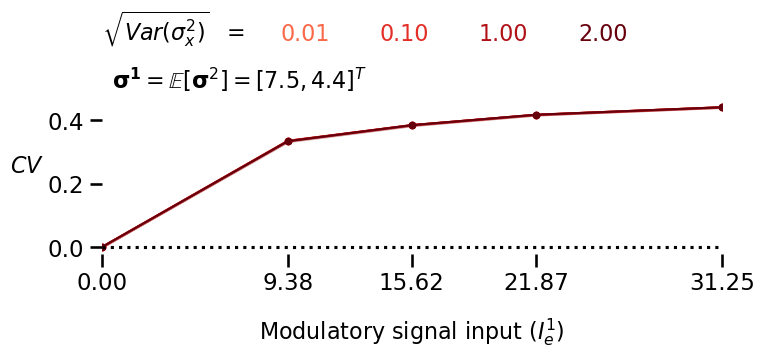

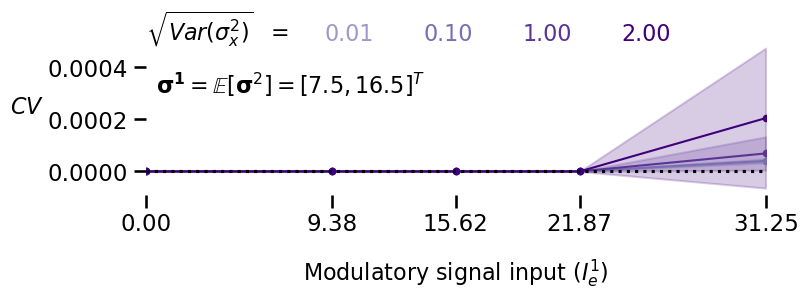

In [96]:
colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0, 0.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, CV[i, :, 0], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, CV[i, :, 0] - CVVar[i, :, 0], CV[i, :, 0] + CVVar[i, :, 0], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 0.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0.5, 0.62, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_sige_2.5_sigi_4.4_I.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 0.45, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, CV[i, :, 1], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, CV[i, :, 1] - CVVar[i, :, 1], CV[i, :, 1] + CVVar[i, :, 1], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 0.45, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0.5, 0.3, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_sige_2.5_sigi_16.5_I.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 0.65, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, CV[i, :, 2], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, CV[i, :, 2] - CVVar[i, :, 2], CV[i, :, 2] + CVVar[i, :, 2], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 0.65, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0.5, 0.5, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_sige_7.5_sigi_4.4_I.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Purples')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 0.0005, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, CV[i, :, 3], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, CV[i, :, 3] - CVVar[i, :, 3], CV[i, :, 3] + CVVar[i, :, 3], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 0.0005, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0.5, 0.0003, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)   
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_sige_7.5_sigi_16.5_I.png"), dpi=300, bbox_inches="tight")
plt.show()